# Tarea U2_S8 - Parte 2: Práctica en Python

**Tema:** Evaluación de un modelo de clasificación con el dataset `breast_cancer` de `sklearn.datasets`.

En este notebook se cumple lo pedido en la práctica:

1. Usar el dataset `breast_cancer`.
2. Entrenar un modelo de **Regresión Logística**.
3. Generar e interpretar la **matriz de confusión**.
4. Calcular **Precisión, Recall, F1-Score y AUC-ROC**.
5. Aplicar **K-Fold Cross-Validation** con `k=5` y `k=10`.
6. Optimizar hiperparámetros con **GridSearchCV** y **RandomizedSearchCV**.
7. Ajustar el **umbral de decisión** y analizar su impacto en las métricas.


In [23]:
# IMPORTACIÓN DE LIBRERÍAS
# numpy: operaciones numéricas
import numpy as np

# pandas: manejo de tablas y DataFrames
import pandas as pd

# matplotlib: gráficos
import matplotlib.pyplot as plt

# loguniform: distribución usada en RandomizedSearchCV para probar valores de C
from scipy.stats import loguniform

# Dataset solicitado por la tarea
from sklearn.datasets import load_breast_cancer

# Herramientas para dividir datos, validar y buscar hiperparámetros
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

# Estandarización de variables numéricas
from sklearn.preprocessing import StandardScaler

# Pipeline para encadenar escalado + modelo
from sklearn.pipeline import Pipeline

# Modelo solicitado por la tarea
from sklearn.linear_model import LogisticRegression

# Métricas de evaluación
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)


## Carga del dataset

Aquí cargamos el conjunto de datos `breast_cancer` desde `sklearn.datasets`.
Se usa `as_frame=True` para trabajar más cómodamente con **DataFrames** de pandas.


In [24]:
# CARGA DEL DATASET
# Cargamos el dataset breast_cancer desde sklearn
data = load_breast_cancer(as_frame=True)

# Separamos variables predictoras y variable objetivo
X = data.data
y = data.target

# Mostramos información básica del dataset
print("Nombre del dataset:")
print(data['DESCR'].split("\n")[0])

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nPrimeras filas de X:")
display(X.head())

print("\nPrimeras filas de y:")
display(y.head())


Nombre del dataset:
.. _breast_cancer_dataset:

Dimensiones de X: (569, 30)
Dimensiones de y: (569,)

Primeras filas de X:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Primeras filas de y:


,target
0,0
1,0
2,0
3,0
4,0


In [25]:
# REVISIÓN BÁSICA DEL DATASET
# Vemos los nombres de las clases objetivo
print("Clases del problema:", data.target_names)

# Revisamos cuántos registros hay por clase
print("\nDistribución de clases:")
print(y.value_counts())

# Comprobamos si hay valores faltantes
print("\nCantidad total de valores nulos en X:")
print(X.isnull().sum().sum())


Clases del problema: ['malignant' 'benign']

Distribución de clases:
target
1    357
0    212
Name: count, dtype: int64

Cantidad total de valores nulos en X:
0


# División entrenamiento y prueba

Se separan los datos en:

- **train**: para que el modelo aprenda
- **test**: para evaluar qué tan bien generaliza con datos no vistos

Se usa `stratify=y` para conservar la proporción de clases.


In [26]:
# DIVISIÓN DE ENTRENAMIENTO Y PRUEBA
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% para prueba
    random_state=42,    # semilla para reproducibilidad
    stratify=y          # mantiene la proporción de clases
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)


Tamaño de X_train: (455, 30)
Tamaño de X_test: (114, 30)
Tamaño de y_train: (455,)
Tamaño de y_test: (114,)


## Modelo base: Regresión Logística

Se usa un **Pipeline** para que el escalado y el modelo queden unidos en un solo flujo.


In [27]:
# PIPELINE CON ESCALADO + REGRESIÓN LOGÍSTICA
# StandardScaler es importante porque la Regresión Logística
# suele funcionar mejor cuando las variables están en escalas comparables.
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

# Entrenamos el modelo con los datos de entrenamiento
pipeline.fit(X_train, y_train)

# Predicciones de clase
y_pred = pipeline.predict(X_test)

# Probabilidades de pertenecer a la clase positiva
# [:, 1] toma la probabilidad de la clase 1
y_prob = pipeline.predict_proba(X_test)[:, 1]


### Matriz de confusión

La matriz de confusión permite ver cuántos casos fueron:

- verdaderos negativos
- falsos positivos
- falsos negativos
- verdaderos positivos


Matriz de confusión:
[[41  1]
 [ 1 71]]


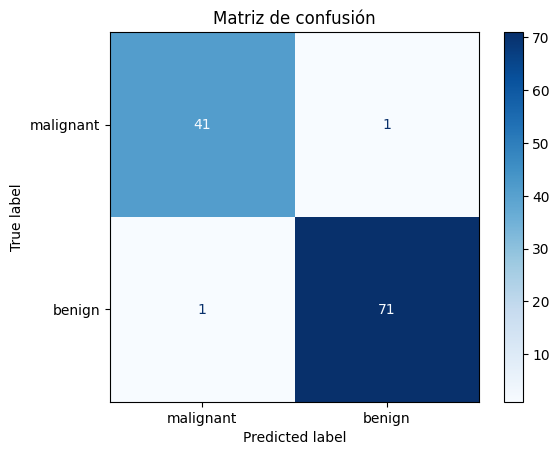

In [28]:
# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(cm)

# Gráfico de la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión")
plt.show()


In [29]:
# INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN
# TN = verdaderos negativos
# FP = falsos positivos
# FN = falsos negativos
# TP = verdaderos positivos
tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos negativos (TN): {tn}")
print(f"Falsos positivos (FP): {fp}")
print(f"Falsos negativos (FN): {fn}")
print(f"Verdaderos positivos (TP): {tp}")


Verdaderos negativos (TN): 41
Falsos positivos (FP): 1
Falsos negativos (FN): 1
Verdaderos positivos (TP): 71


## Métricas principales

Se calculan las métricas:

- **Precisión**
- **Recall**
- **F1-Score**
- **AUC-ROC**


In [30]:
# MÉTRICAS DE EVALUACIÓN
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Precisión:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))
print("AUC-ROC:", round(auc, 4))


Precisión: 0.9861
Recall: 0.9861
F1-Score: 0.9861
AUC-ROC: 0.9954


In [31]:
# REPORTE DE CLASIFICACIÓN
print("Reporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Reporte de clasificación:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



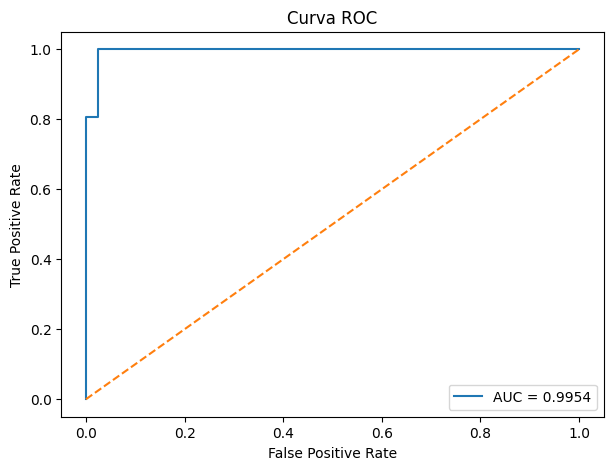

In [32]:
# CURVA ROC
# fpr: false positive rate
# tpr: true positive rate
# thresholds: umbrales evaluados
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()


## Validación cruzada con K-Fold

Aquí se compara el desempeño usando:

- `k = 5`
- `k = 10`

Se utiliza **StratifiedKFold** para respetar la proporción de clases.
La métrica elegida para comparar es **AUC-ROC**.


In [33]:
# K-FOLD CON K=5
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_val_score entrena y evalúa el pipeline en cada fold
scores_cv5 = cross_val_score(pipeline, X, y, cv=cv5, scoring="roc_auc")

print("Resultados de AUC-ROC con K=5:")
print(scores_cv5)
print("Promedio:", round(scores_cv5.mean(), 4))
print("Desviación estándar:", round(scores_cv5.std(), 4))


Resultados de AUC-ROC con K=5:
[0.9950868  0.99770717 0.98511905 1.         0.99865862]
Promedio: 0.9953
Desviación estándar: 0.0053


In [34]:
# K-FOLD CON K=10
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores_cv10 = cross_val_score(pipeline, X, y, cv=cv10, scoring="roc_auc")

print("Resultados de AUC-ROC con K=10:")
print(scores_cv10)
print("Promedio:", round(scores_cv10.mean(), 4))
print("Desviación estándar:", round(scores_cv10.std(), 4))


Resultados de AUC-ROC con K=10:
[0.99220779 0.9987013  0.99603175 0.99603175 0.97751323 0.99074074
 1.         1.         0.99603175 1.        ]
Promedio: 0.9947
Desviación estándar: 0.0065


In [35]:
# TABLA COMPARATIVA K=5 VS K=10
comparacion_cv = pd.DataFrame({
    "Método": ["K-Fold 5", "K-Fold 10"],
    "AUC promedio": [scores_cv5.mean(), scores_cv10.mean()],
    "Desviación estándar": [scores_cv5.std(), scores_cv10.std()]
})

display(comparacion_cv)


,Método,AUC promedio,Desviación estándar
0,K-Fold 5,0.995314,0.005345
1,K-Fold 10,0.994726,0.006503


## Optimización de hiperparámetros

Se aplican los dos métodos:

- **GridSearchCV**
- **RandomizedSearchCV**

En ambos casos se optimiza el parámetro `C` del modelo de Regresión Logística.


In [36]:
# GRIDSEARCHCV
# Definimos una grilla fija de valores para probar
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"],
    "model__penalty": ["l2"]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

# Entrenamos la búsqueda exhaustiva
grid.fit(X_train, y_train)

print("Mejores parámetros con GridSearchCV:")
print(grid.best_params_)
print("Mejor score:", round(grid.best_score_, 4))


Mejores parámetros con GridSearchCV:
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Mejor score: 0.9941


In [37]:
# RANDOMIZEDSEARCHCV
# Aquí no probamos todos los valores, sino una muestra aleatoria
param_dist = {
    "model__C": loguniform(1e-3, 1e2),
    "model__solver": ["liblinear", "lbfgs"],
    "model__penalty": ["l2"]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=42
)

# Entrenamos la búsqueda aleatoria
random_search.fit(X_train, y_train)

print("Mejores parámetros con RandomizedSearchCV:")
print(random_search.best_params_)
print("Mejor score:", round(random_search.best_score_, 4))


Mejores parámetros con RandomizedSearchCV:
{'model__C': np.float64(0.0745934328572655), 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Mejor score: 0.994


In [38]:
# COMPARACIÓN GRID VS RANDOM
comparacion_busqueda = pd.DataFrame({
    "Método": ["GridSearchCV", "RandomizedSearchCV"],
    "Mejor score": [grid.best_score_, random_search.best_score_]
})

display(comparacion_busqueda)


,Método,Mejor score
0,GridSearchCV,0.994118
1,RandomizedSearchCV,0.994014


## Evaluación del mejor modelo

Aquí se toma como mejor modelo el encontrado por **GridSearchCV**.
Luego se vuelven a calcular las métricas sobre el conjunto de prueba.


In [39]:
# EVALUACIÓN DEL MEJOR MODELO
best_model = grid.best_estimator_

# Nuevas predicciones con el mejor modelo
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("Métricas del mejor modelo:")
print("Precisión:", round(precision_score(y_test, y_pred_best), 4))
print("Recall:", round(recall_score(y_test, y_pred_best), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_best), 4))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_best), 4))


Métricas del mejor modelo:
Precisión: 0.9861
Recall: 0.9861
F1-Score: 0.9861
AUC-ROC: 0.996


## Ajuste del umbral de decisión

La Regresión Logística devuelve probabilidades.  
Aquí se comparan:

- `0.3`
- `0.5`
- `0.7`


In [40]:
# AJUSTE DEL UMBRAL DE DECISIÓN
thresholds_to_test = [0.3, 0.5, 0.7]

results = []

for th in thresholds_to_test:
    # Convertimos probabilidades en clases según el umbral elegido
    y_pred_th = (y_prob_best >= th).astype(int)

    # Guardamos las métricas para cada umbral
    results.append({
        "Umbral": th,
        "Precisión": precision_score(y_test, y_pred_th),
        "Recall": recall_score(y_test, y_pred_th),
        "F1-Score": f1_score(y_test, y_pred_th)
    })

results_df = pd.DataFrame(results)
display(results_df)


,Umbral,Precisión,Recall,F1-Score
0,0.3,0.947368,1.000000,0.972973
1,0.5,0.986111,0.986111,0.986111
2,0.7,0.984615,0.888889,0.934307


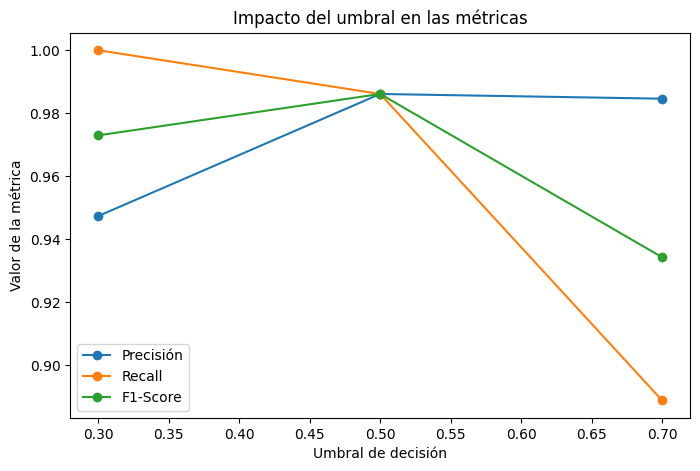

In [41]:
# VISUALIZACIÓN DEL IMPACTO DEL UMBRAL
plt.figure(figsize=(8, 5))
plt.plot(results_df["Umbral"], results_df["Precisión"], marker="o", label="Precisión")
plt.plot(results_df["Umbral"], results_df["Recall"], marker="o", label="Recall")
plt.plot(results_df["Umbral"], results_df["F1-Score"], marker="o", label="F1-Score")

plt.xlabel("Umbral de decisión")
plt.ylabel("Valor de la métrica")
plt.title("Impacto del umbral en las métricas")
plt.legend()
plt.show()


In [42]:
# INTERPRETACIÓN
print("Interpretación:")
print("- Cuando el umbral baja, el modelo suele detectar más positivos, por eso sube el recall.")
print("- Cuando el umbral sube, el modelo se vuelve más estricto, por eso suele subir la precisión.")
print("- El mejor umbral depende del problema y del costo de cometer falsos positivos o falsos negativos.")


Interpretación:
- Cuando el umbral baja, el modelo suele detectar más positivos, por eso sube el recall.
- Cuando el umbral sube, el modelo se vuelve más estricto, por eso suele subir la precisión.
- El mejor umbral depende del problema y del costo de cometer falsos positivos o falsos negativos.
